In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from ellipse import LsqEllipse

In [2]:
import pickle

wray_qphi = pickle.load(open('wray_qphi', 'rb'))
wray_qphi_d = pickle.load(open('wray_qphi_d', 'rb'))
wray_qphi_polar_extended = pickle.load(open('wray_qphi_polar_extended', 'rb'))

In [3]:
wray_res = fits.open('SPHERE_residuals.fits')
wray_hdu = wray_res[0]
wray_hdu.header

SIMPLE  =                    T / Written by IDL:  Fri Sep 05 12:54:48 2025      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    2 / Number of data axes                            
NAXIS1  =                  200 /                                                
NAXIS2  =                  200 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2025-09-05'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    

(200, 200)


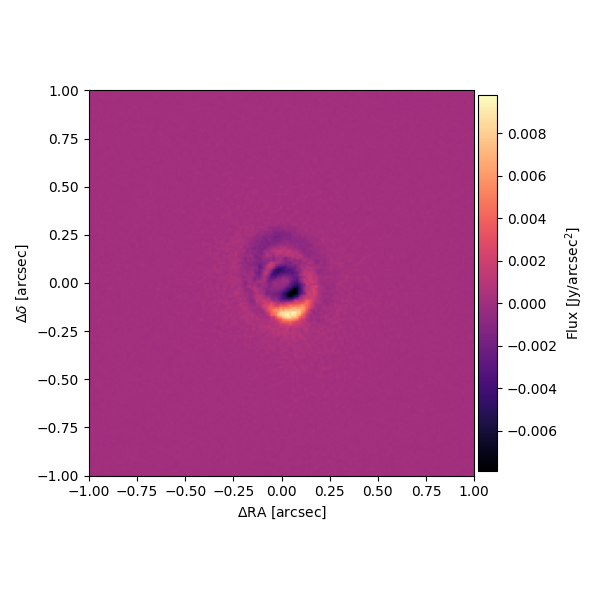

In [21]:
wray_res = wray_hdu.data

print (np.shape(wray_res))

scale = 12.251/1000. # number of arcsec/px

extent = [
    -wray_res.shape[1] * scale / 2,  # Left = -width/2 (as)
    wray_res.shape[1] * scale / 2,   # Right = +width/2 (as)
    -wray_res.shape[0] * scale / 2,  # Bottom = -height/2 (as)
    wray_res.shape[0] * scale / 2,   # Top = +height/2 (as)
]

fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(wray_res, origin='lower', cmap='magma', extent=extent)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Flux [Jy/arcsec$^2$]")
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

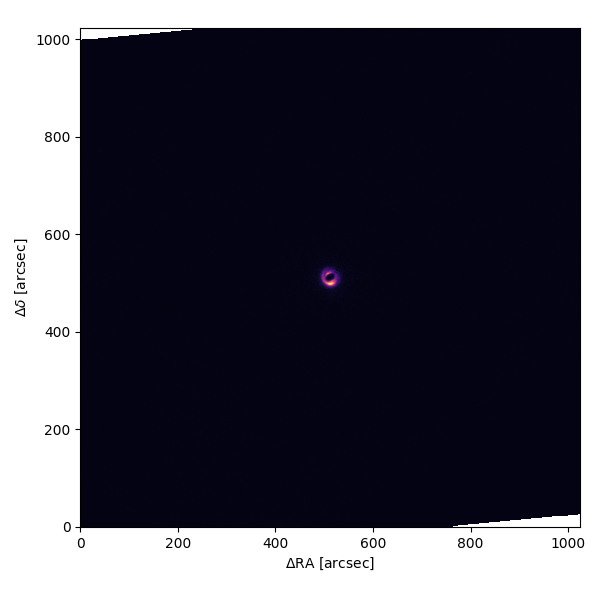

In [5]:
# Let us see the deprojeccted disk image:
# Define circle parameters
scale = 12.251/1000. # number of arcsec/px

extent = [
    -wray_qphi.shape[1] * scale / 2,  # Left = -width/2 (as)
    wray_qphi.shape[1] * scale / 2,   # Right = +width/2 (as)
    -wray_qphi.shape[0] * scale / 2,  # Bottom = -height/2 (as)
    wray_qphi.shape[0] * scale / 2,   # Top = +height/2 (as)
]

plt.figure(figsize=(6, 6))
plt.imshow(wray_qphi_d, origin='lower', cmap='magma')
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')
#plt.xlim(-0.75, 0.75)
#plt.ylim(-0.75, 0.75)
plt.tight_layout()
plt.show()

In [6]:
from matplotlib.patches import Rectangle

def make_bordered_rectangle(x_base, y_base, width, height, thickness=0.5, label='', color='w', alpha=1.):
    
    # Calculate bottom-left corner coordinates (since Rectangle uses this)
    bottom_left_x = x_base - width / 2
    bottom_left_y = y_base  # Base starts at y_base, extends upwards

    # Create the rectangle patch (only border, no fill)
    rect = Rectangle(
        (bottom_left_x, bottom_left_y),
        width, height,
        linewidth=thickness,
        edgecolor=color,
        facecolor='none',  # Transparent inside
        alpha=alpha,
        label=label
    )

    # Add to the current axis
    plt.gca().add_patch(rect)

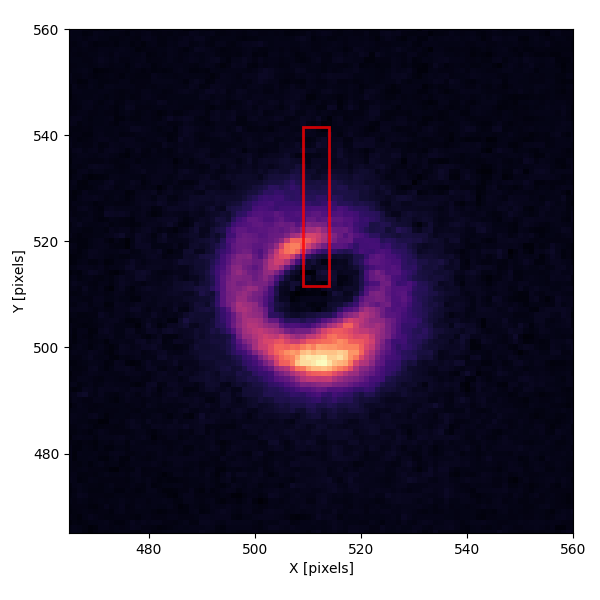

In [7]:
x_center = 511.5
y_center = 511.5
r_width = 5
r_height = 30

plt.figure(figsize=(6,6))
plt.imshow(wray_qphi_d, origin='lower', cmap='magma')
make_bordered_rectangle(
    x_base=x_center, y_base=y_center, 
    width=r_width, height=r_height, 
    thickness=2.0,  # Thicker border
    color='red', 
    alpha=0.8,
    label='Slit'
)
plt.xlabel('X [pixels]')
plt.ylabel('Y [pixels]')
plt.xlim(465, 560)
plt.ylim(465, 560)
plt.tight_layout()
plt.show()

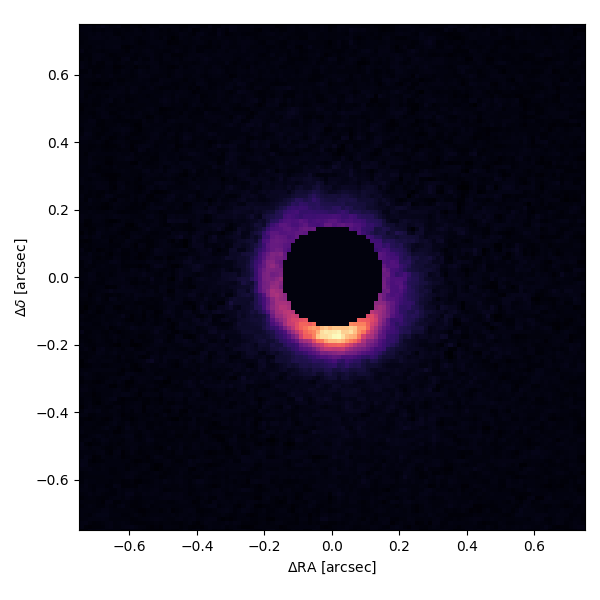

In [8]:
# Define circle radius
radius = 0.15  # arcsec

# Create coordinate arrays based on extent
x = np.linspace(extent[0], extent[1], wray_qphi_d.shape[1])
y = np.linspace(extent[2], extent[3], wray_qphi_d.shape[0])

# Create mask using broadcasting
xx, yy = np.meshgrid(x, y)
mask = (xx**2 + yy**2) <= radius**2

# Apply mask
wray_qphi_d_masked = wray_qphi_d.copy()
wray_qphi_d_masked[mask] = 0

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(wray_qphi_d_masked, origin='lower', cmap='magma', extent=extent)
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.tight_layout()
plt.show()

In [9]:
from matplotlib.patches import Polygon

def rotated_rectangle(x_base, y_base, width, height, angle_deg=0):
    """
    Generate vertices of a rotated rectangle centered at the midpoint of its base.
    
    Parameters:
    - x_base, y_base: Midpoint of the base before rotation.
    - width, height: Dimensions of the rectangle.
    - angle_deg: Rotation angle in degrees (counter-clockwise).
    
    Returns:
    - vertices: 4x2 array of rotated rectangle vertices.
    """
    angle_rad = np.deg2rad(angle_deg)
    
    # Unrotated vertices (anchored at midpoint of base)
    half_width = width / 2
    vertices = np.array([
        [-half_width, 0],      # Bottom-left
        [half_width, 0],       # Bottom-right
        [half_width, height],  # Top-right
        [-half_width, height]  # Top-left
    ])
    
    # Rotation matrix
    rot_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    
    # Rotate and translate vertices
    rotated_vertices = np.dot(vertices, rot_matrix.T) + np.array([x_base, y_base])
    
    return rotated_vertices

def calculate_flux_in_rotated_rectangle(image, vertices):
    """
    Calculate flux inside a rotated rectangle defined by its vertices.
    
    Parameters:
    - image: 2D numpy array (image data).
    - vertices: 4x2 array of rectangle vertices.
    
    Returns:
    - Total flux inside the polygon.
    - Mask of the polygon (for visualization).
    """
    from matplotlib.path import Path
    
    # Create a meshgrid of pixel coordinates
    y_pixels, x_pixels = np.indices(image.shape)
    pixel_coords = np.column_stack((x_pixels.ravel(), y_pixels.ravel()))
    
    # Create a Path for the rotated rectangle
    rect_path = Path(vertices)
    
    # Check which pixels are inside the path
    mask = rect_path.contains_points(pixel_coords).reshape(image.shape)
    
    # Calculate total flux
    flux = np.sum(image[mask])
    
    return flux, mask

In [10]:
from skimage.draw import polygon

def calculate_flux_all_angles(image, center_x, center_y, width, height, angle_range=np.arange(360)):
    """Vectorized calculation of flux in rotated rectangles."""
    max_flux = 0
    flux_results = np.zeros_like(angle_range, dtype=np.float64)
    
    for i, angle in enumerate(angle_range):
        # Create rotated rectangle vertices
        rect = rotated_rectangle(center_x, center_y, width, height, angle_deg=angle)
        
        # Convert rectangle to mask using polygon
        rr, cc = polygon(rect[:, 1], rect[:, 0], image.shape)
        flux = np.sum(image[rr, cc])
        
        flux_results[i] = flux
        if flux > max_flux:
            max_flux = flux
    
    return angle_range, flux_results, flux_results / max_flux

angle, flux_results, norm_flux = calculate_flux_all_angles(wray_qphi_d_masked, x_center, y_center, r_width, r_height, angle_range=np.arange(360))

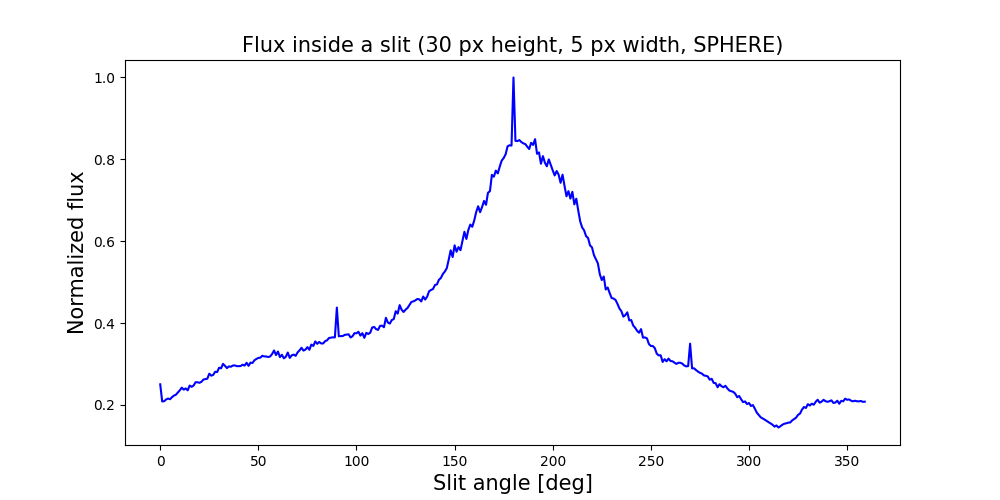

In [11]:
plt.figure(figsize=(10, 5))
plt.title('Flux inside a slit (30 px height, 5 px width, SPHERE)', fontsize=15)
plt.plot(angle, norm_flux, 'b')
#plt.plot(angle, norm_flux_mask, 'b', label='mask')
plt.ylabel('Normalized flux', fontsize=15)
plt.xlabel('Slit angle [deg]', fontsize=15)
plt.show()

In [12]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def gaussian(x, amplitude, mean, stddev):
    """Gaussian function for fitting."""
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

def mask_peaks(signal, height_threshold, distance=10):
    """Finds peaks and returns a mask (True where no peaks are)."""
    peaks, _ = find_peaks(signal, height=height_threshold, distance=distance)
    mask = np.ones_like(signal, dtype=bool)
    mask[peaks] = False  # Exclude peaks from fit
    return mask

def fit_gaussian_excluding_peaks(x, y, height_threshold):
    """Fits a Gaussian while excluding peaks."""
    mask = mask_peaks(y, height_threshold)
    x_fit = x[mask]
    y_fit = y[mask]
    
    # Initial guess for Gaussian parameters
    mean_guess = np.mean(x_fit)
    std_guess = np.std(x_fit)
    amplitude_guess = np.max(y_fit)
    
    # Fit Gaussian
    popt, pcov = curve_fit(gaussian, x_fit, y_fit, 
                          p0=[amplitude_guess, mean_guess, std_guess])
    
    return popt, pcov  # Optimal parameters and covariance

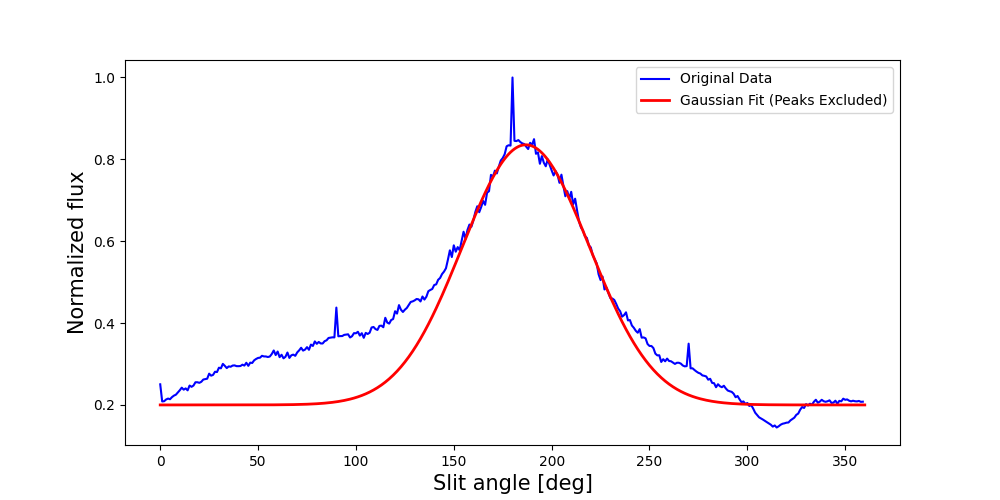

In [13]:
# Fit Gaussian while excluding peaks
height_threshold = 0.03  # Adjust based on your data

# Selecting only the luminosity peak that interests us:
mask = (angle >= 160) & (angle <= 220)
angle_masked = angle[mask]
norm_flux_masked = norm_flux[mask]
popt, pcov = fit_gaussian_excluding_peaks(angle_masked, norm_flux_masked-0.2, height_threshold)

# Reconstruct the fitted Gaussian
angle_fit = np.arange(361)
norm_flux_fit = gaussian(angle_fit, *popt) + 0.2

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(angle, norm_flux, 'b-', label="Original Data")
plt.plot(angle_fit, norm_flux_fit, 'r-', linewidth=2, label="Gaussian Fit (Peaks Excluded)")
plt.ylabel('Normalized flux', fontsize=15)
plt.xlabel('Slit angle [deg]', fontsize=15)
plt.legend()
plt.show()

In [14]:
perr = np.sqrt(np.diag(pcov))

print ('fitted parameters:', popt)
print ('errors on the fitted parameters:', perr)
print ('final peak angle value:',f'{popt[1]: .1f} \u00B1 {perr[1]: .1f}', 'deg')
print ('final width of the blob:', f'{2*popt[2]: .1f} \u00B1 {2*perr[2]: .1f}', 'deg')

fitted parameters: [  0.63560087 186.83008017  32.5610339 ]
errors on the fitted parameters: [0.00279791 0.22331448 0.43159839]
final peak angle value:  186.8 ±  0.2 deg
final width of the blob:  65.1 ±  0.9 deg


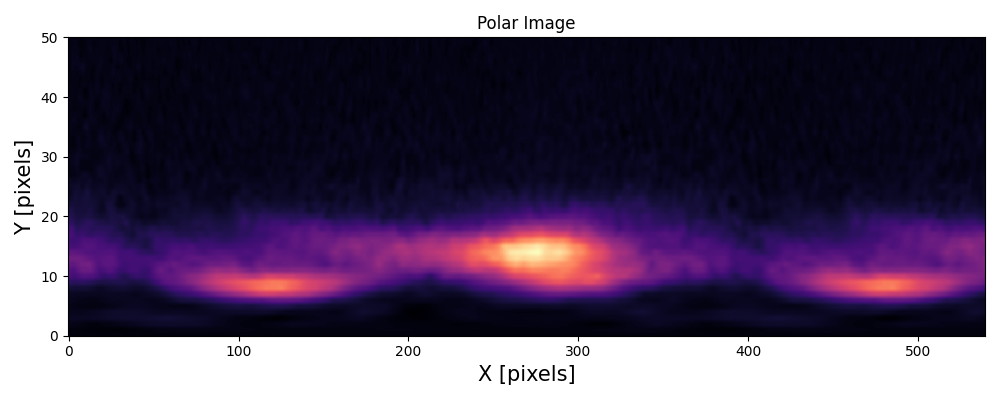

In [15]:
AU_scale = 1.89 # AU/pixel (at a distance of 151 pc)
p_extent = [-np.pi/2., np.pi*5./2., 0, wray_qphi_polar_extended.shape[0] * AU_scale]

plt.figure(figsize=(10, 4))
#plt.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', extent=p_extent, aspect='auto', norm=LogNorm(vmin=10**-8, vmax=np.nanmax(wray_qphi_polar_extended)))
plt.imshow(wray_qphi_polar_extended, origin='lower', cmap='magma', aspect='auto')
plt.xlabel('X [pixels]', fontsize=15)
plt.ylabel('Y [pixels]', fontsize=15)
plt.ylim(0, 50)
plt.title('Polar Image')
plt.tight_layout()
plt.show()

In [16]:
# Define a noise region (adjust coordinates to a blank area)
noise_region = wray_qphi_d[700:800, 500:600]  # Example: top-left corner

# Calculate RMS
rms = np.std(noise_region)
print(f"Estimated RMS noise: {rms:.2e} Jy/arcsec^2")

Estimated RMS noise: 3.53e-09 Jy/arcsec^2


[0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989 0.00399989
 0.00399989 0.00399989]


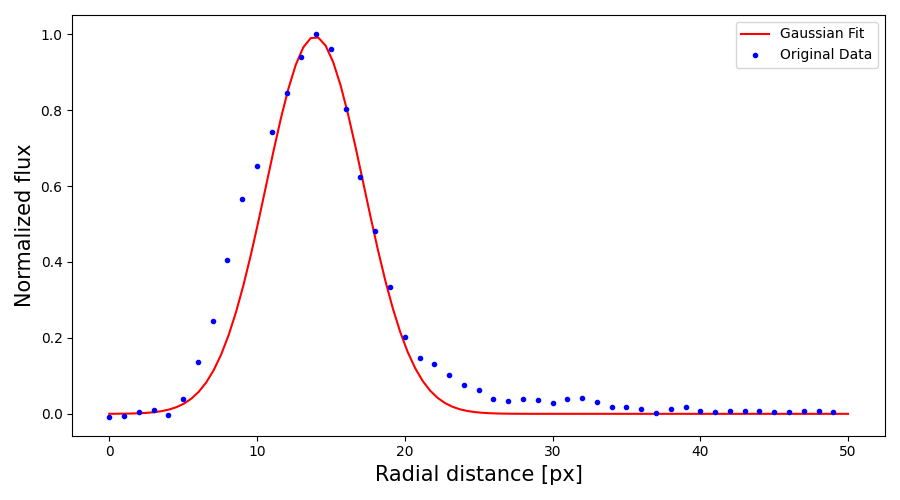

In [17]:
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, stddev):
    """Gaussian function for fitting."""
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

radii = np.arange(50)
profile = wray_qphi_polar_extended[0:50, 277]
# Fit Gaussian while excluding peaks
height_threshold = 0.03  # Adjust based on your data

norm_flux = profile / np.nanmax(profile)
norm_error_flux = (rms / np.nanmax(profile)) * np.ones(len(norm_flux))

print (norm_error_flux)

# Selecting only the luminosity peak that interests us:
mask = (radii >= 12) & (radii <= 18)
radii_masked = radii[mask]
norm_flux_masked = norm_flux[mask]
p0 = [1, 15, 5]
popt, pcov = curve_fit(gaussian, radii_masked, norm_flux_masked, p0=p0)

radii_fit = np.linspace(0, 50, 100)

# Reconstruct the fitted Gaussian
norm_flux_fit = gaussian(radii_fit, *popt)

# Plot results
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(radii, norm_flux, fmt='bo', markersize=3, capsize=3, label="Original Data")
ax.plot(radii_fit, norm_flux_fit, 'r-', label="Gaussian Fit")
ax.set_ylabel('Normalized flux', fontsize=15)
ax.set_xlabel('Radial distance [px]', fontsize=15)
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
perr = np.sqrt(np.diag(pcov))

print ('fitted parameters:', popt)
print ('errors on the fitted parameters:', perr)
print ('peak value:', f'{popt[1]*AU_scale: .1f} \u00B1 {perr[1]*AU_scale: .1f} AU')
print ('radial width of the blob:', f'{2*popt[2]*AU_scale: .1f} \u00B1 {2*perr[2]*AU_scale: .1f} AU')

fitted parameters: [ 0.99326817 13.92328315  3.3001877 ]
errors on the fitted parameters: [0.01156062 0.07595549 0.10698205]
peak value:  26.3 ±  0.1 AU
radial width of the blob:  12.5 ±  0.4 AU
